# Acquisition Function Output Analysis

Load a saved active-learning `output_dict` HDF5 file and start with the mean test reduced-error plot.

In [16]:
%matplotlib inline

from pathlib import Path
import re

import h5py
import numpy as np
import matplotlib.pyplot as plt


cwd = Path.cwd()
stm_dir = cwd /"notebooks" / "STM" if (cwd / "notebooks" / "STM").exists() else cwd
results_dir = stm_dir /  "active_learning_results_ms2"

h5_files = sorted(results_dir.glob("*.h5"), key=lambda path: path.stat().st_mtime)
if not h5_files:
    raise FileNotFoundError(f"No .h5 files found in {results_dir}")


# By default, analyze the newest saved acquisition result. Replace this with
# a specific Path(...) if you want to load a different run.
output_file = h5_files[-1]
output_file



error_type = "L1"  # "L1", "L2", or "cos"
acquisition_iterations = 50
num_new_points = 5
output_file = results_dir / (
    f"al_im2spec_{error_type}_WS32_latent5_appendpad_"
    f"{acquisition_iterations}iters_{num_new_points}pts_randomacq.h5"
)


In [17]:
def plot_reduced_errors_and_scales(errors, coords_reduced, aq_indices=None):
    xs = coords_reduced[:, 0]
    ys = coords_reduced[:, 1]
    scales = coords_reduced[:, 2]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sc0 = axes[0].scatter(xs, ys, c=errors, s=80)
    axes[0].set_title("Reduced Minimum Errors, mean = {:.3f}".format(np.mean(errors)))
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect("equal")
    plt.colorbar(sc0, ax=axes[0], label="Minimum Error")

    sc1 = axes[1].scatter(xs, ys, c=scales, s=80)
    axes[1].set_title("Best Scale at Each (x, y)")
    axes[1].set_xlabel("x (nm)")
    axes[1].set_ylabel("y (nm)")
    axes[1].set_aspect("equal")
    plt.colorbar(sc1, ax=axes[1], label="Best Scale (nm)")

    if aq_indices is not None and len(aq_indices) > 0:
        aq_indices = np.asarray(aq_indices, dtype=int)

        axes[0].scatter(
            xs[aq_indices],
            ys[aq_indices],
            marker="x",
            s=120,
            linewidths=2,
            label="Acquisition points",
        )
        axes[0].legend()

    plt.tight_layout()
    plt.show()


def load_h5_ragged(filename):
    data_dict = {}

    with h5py.File(filename, "r") as f:
        for key in f.keys():
            group = f[key]

            values = []
            for i in range(len(group)):
                values.append(group[str(i)][()])

            data_dict[key] = values

    return data_dict


def infer_num_new_points(output_dict, output_file, fallback=5):
    match = re.search(r"_(\d+)pts_", output_file.name)
    if match:
        return int(match.group(1))

    train_indices = output_dict.get("train_indices", [])
    if len(train_indices) > 1:
        return int(len(train_indices[1]) - len(train_indices[0]))

    return fallback



In [13]:


output_dict = load_h5_ragged(output_file)
{key: len(value) for key, value in output_dict.items()}

{'im2spec_test_mismatches': 50,
 'pred_error_test': 50,
 'predicted_errors_all': 50,
 'reduced_coords': 50,
 'reduced_errors': 50,
 'reduced_errors_im2spec': 50,
 'test_indices': 50,
 'train_indices': 50}

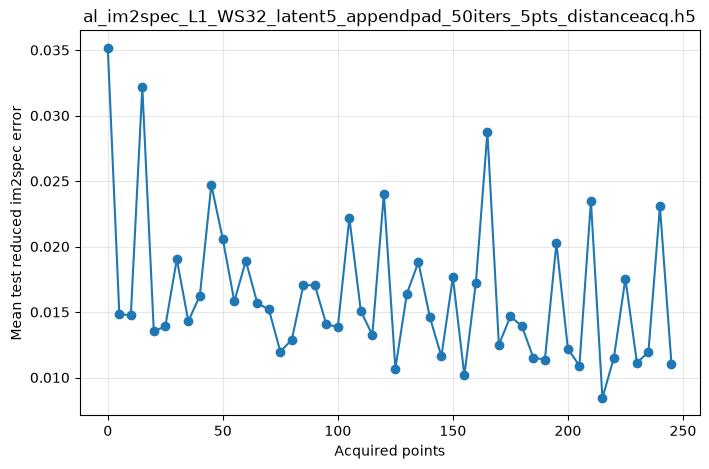

In [14]:


train_indices_arr = output_dict["train_indices"]
test_indices_arr = [indices.astype(int) for indices in output_dict["test_indices"]]
reduced_errors_arr = np.array(output_dict["reduced_errors_im2spec"])

num_saved_iterations = len(reduced_errors_arr)
points_per_iteration = infer_num_new_points(output_dict, output_file)

test_reduced_errors = [
    reduced_errors_arr[i][test_indices_arr[i]]
    for i in range(num_saved_iterations)
]

mean_test_reduced_errors = [
    np.mean(test_reduced_errors[i])
    for i in range(num_saved_iterations)
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(num_saved_iterations) * points_per_iteration,
    mean_test_reduced_errors,
    marker="o",
)
ax.set_xlabel("Acquired points")
ax.set_ylabel("Mean test reduced im2spec error")
ax.set_title(Path(output_file).name)
ax.grid(True, alpha=0.3)
plt.show()

Plotting iteration 0 from al_im2spec_L1_WS32_latent5_appendpad_50iters_5pts_randomacq.h5


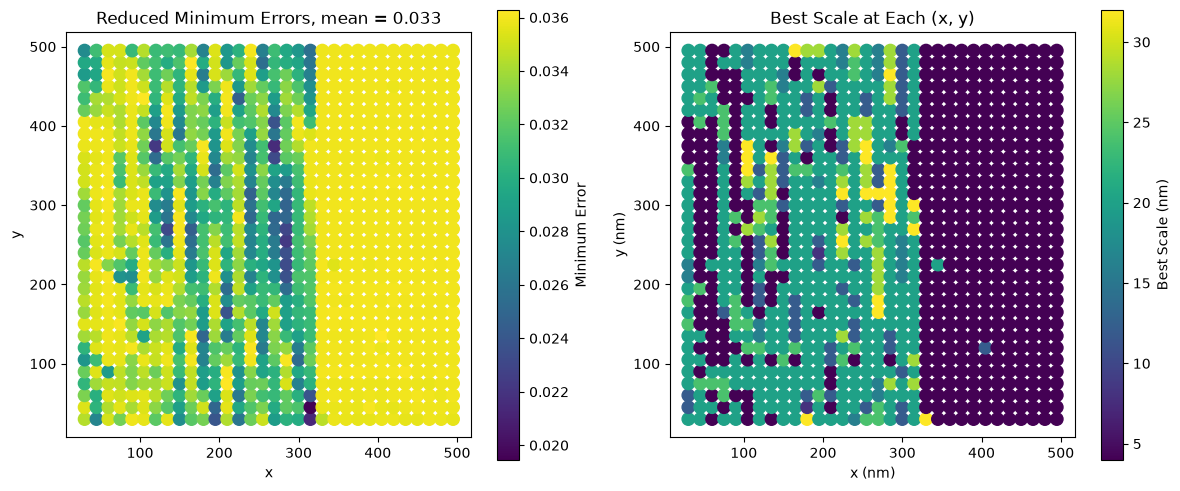

In [20]:
plot_iteration = 0
error_key = "reduced_errors"

if "reduced_coords" not in output_dict:
    raise KeyError(
        "This output file does not contain reduced_coords. "
        "Re-run stm_ms_acqfn_script.py after the reduced_coords save change."
    )

reduced_errors_to_plot = np.asarray(output_dict[error_key][plot_iteration])
reduced_coords_to_plot = np.asarray(output_dict["reduced_coords"][plot_iteration])

print(f"Plotting iteration {plot_iteration} from {Path(output_file).name}")
plot_reduced_errors_and_scales(reduced_errors_to_plot, reduced_coords_to_plot)

In [8]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
def plot_error_prediction_3d(
    error_mean,
    aq_fn,
    coordinates,
    ind,
    expt_name="test_expt",
    iter_nb=0,
    save_folder=r"data",
    to_save=False,
    alpha_scale=True,
    colormap="viridis",
):
    """
    Plot 3D scatter maps of predicted error and acquisition values.

    Args:
        error_mean: Flat array of error values.
        aq_fn: Flat array of acquisition values.
        coordinates: Either `(nx, ny, nz, 3)` gridded coordinates or `(N, 3)`
            flat coordinates. `error_mean` and `aq_fn` must match the flattened
            coordinate order.
        ind: Candidate index or indices selected for acquisition. Currently
            retained for API consistency.
        expt_name: Subfolder name used when saving.
        iter_nb: Iteration number included in the saved filename.
        save_folder: Root folder for saved figures.
        to_save: If True, save the figure before showing it.
        alpha_scale: If True, scale point alpha by normalized values.
        colormap: Matplotlib colormap name.

    Raises:
        ValueError: If coordinate dimensions or flattened lengths are invalid.
    """

    coordinates = np.asarray(coordinates)

    # ---------------------------------------------------------------
    # 1. Get per-axis sizes from `coordinates` -- no cubic assumption.
    # ---------------------------------------------------------------
    if coordinates.ndim == 4:
        nx, ny, nz, _ = coordinates.shape
        coords_flat = coordinates.reshape(-1, 3)
    elif coordinates.ndim == 2:
        nx = len(np.unique(coordinates[:, 0]))
        ny = len(np.unique(coordinates[:, 1]))
        nz = len(np.unique(coordinates[:, 2]))
        coords_flat = coordinates
    else:
        raise ValueError(
            f"coordinates must be 2D (N, 3) or 4D (nx, ny, nz, 3), "
            f"got shape {coordinates.shape}"
        )

    n_total = nx * ny * nz
    if len(error_mean) != n_total or len(aq_fn) != n_total:
        raise ValueError(
            f"Length mismatch: coordinates imply {n_total} points "
            f"(nx={nx}, ny={ny}, nz={nz}), but got "
            f"error_mean of length {len(error_mean)} and "
            f"aq_fn of length {len(aq_fn)}."
        )

    err_flat = np.asarray(error_mean).ravel()
    aq_flat  = np.asarray(aq_fn).ravel()

    nm_per_pixel = 0.4833
    xs = coords_flat[:, 0] * nm_per_pixel
    ys = coords_flat[:, 1] * nm_per_pixel
    zs = coords_flat[:, 2] * nm_per_pixel

    # ---------------------------------------------------------------
    # 2. Helper: build per-point RGBA so alpha is baked into the color.
    #    3D scatter chokes when you pass `alpha=` as an array, so we
    #    sidestep that path entirely.
    # ---------------------------------------------------------------
    def values_to_rgba(values, cmap_name="viridis", vmin=None, vmax=None,
                       min_alpha=0.05, max_alpha=0.9, use_alpha=True):
        """Convert scalar values to RGBA colors and a normalization object."""
        v = values.astype(float)
        lo = v.min() if vmin is None else vmin
        hi = v.max() if vmax is None else vmax
        rng = hi - lo
        norm = (v - lo) / rng if rng > 0 else np.zeros_like(v)
        rgba = plt.get_cmap(cmap_name)(norm)
        if use_alpha:
            rgba[:, -1] = min_alpha + norm * (max_alpha - min_alpha)
        return rgba, Normalize(vmin=lo, vmax=hi)

    err_rgba, err_norm = values_to_rgba(err_flat, cmap_name=colormap, use_alpha=alpha_scale)
    aq_rgba,  aq_norm  = values_to_rgba(aq_flat, cmap_name=colormap, vmin=0, use_alpha=alpha_scale)

    # ---------------------------------------------------------------
    # 3. Two 3D scatter subplots.
    # ---------------------------------------------------------------
    fig = plt.figure(figsize=(12, 5))
    ax0 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1 = fig.add_subplot(1, 2, 2, projection="3d")

    # --- Error map ---
    ax0.scatter(xs, ys, zs, c=err_rgba, s=20, edgecolors="none")

    # highlight the next selected point
    # ax0.scatter(
    #     xs[ind], ys[ind], zs[ind],
    #     c="red", s=80, edgecolors="black", linewidths=1.0,
    #     depthshade=False,
    # )
    ax0.set_title("Error Map")
    ax0.set_xlabel("x(nm)"); ax0.set_ylabel("y(nm)"); ax0.set_zlabel("Scale (nm)")
    fig.colorbar(ScalarMappable(norm=err_norm, cmap=colormap),
                 ax=ax0, fraction=0.04, pad=0.08)

    # --- Acquisition function ---
    ax1.scatter(xs, ys, zs, c=aq_rgba, s=20, edgecolors="none")
    ax1.set_title("Acquisition Function")
    ax1.set_xlabel("x(nm)"); ax1.set_ylabel("y(nm)"); ax1.set_zlabel("z(nm)")
    fig.colorbar(ScalarMappable(norm=aq_norm, cmap=colormap),
                 ax=ax1, fraction=0.04, pad=0.08)

    plt.tight_layout()

    # ---------------------------------------------------------------
    # 4. Optional save.
    # ---------------------------------------------------------------
    if to_save:
        img_name = "errormap_iter" + str(iter_nb) + ".jpg"
        out_dir = os.path.join(save_folder, expt_name)
        os.makedirs(out_dir, exist_ok=True)
        img_path = os.path.join(out_dir, img_name)
        plt.savefig(img_path, bbox_inches="tight")

    plt.show()

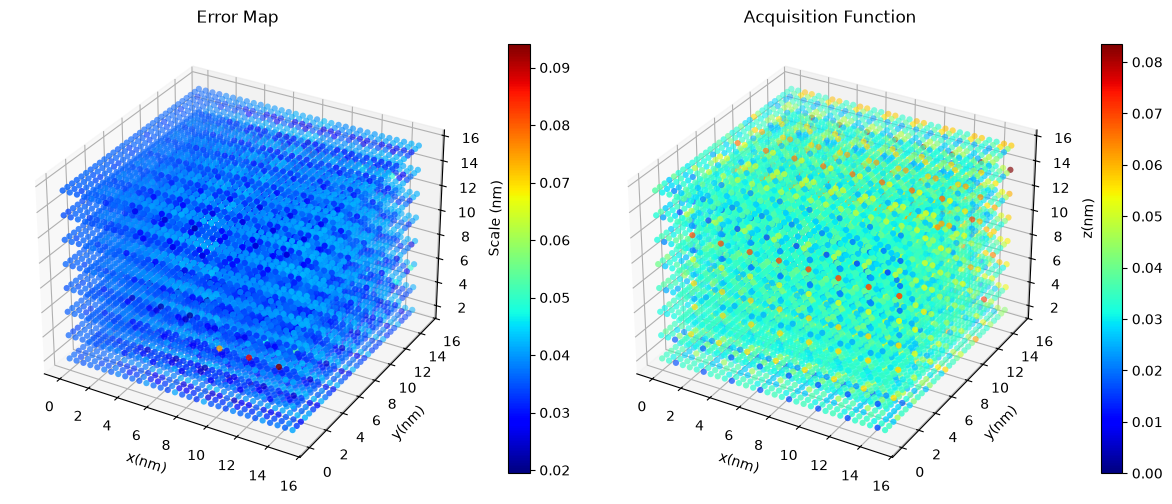

In [21]:
# --- Extract arrays ---
error_mean = output_dict["predicted_errors_all"][0]     # length 8192
aq_fn_base = output_dict["reduced_errors_im2spec"][0]   # length 1024

aq_fn = np.tile(aq_fn_base, 8)   

# --- Build scales array ---
scales = np.arange(4, 36, 4)     

nx, ny, nz = 32, 32, len(scales)
x = np.arange(nx)
y = np.arange(ny)
z = np.arange(nz)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
coordinates_full = np.stack([X, Y, Z], axis=-1)  

# Replace z-axis with scales
for k in range(nz):
    coordinates_full[:, :, k, 2] = scales[k]

# Flatten to (8192, 3)
coords_flat = coordinates_full.reshape(-1, 3)

# --- Plot ---
plot_error_prediction_3d(
    error_mean=error_mean,   # 8192
    aq_fn=aq_fn,             # 8192
    coordinates=coords_flat, # 8192
    ind=output_dict["train_indices"][0],
    expt_name="im2spec_expt",
    iter_nb=len(output_dict["train_indices"]) - 1,
    save_folder="data/plots",
    to_save=False,
    alpha_scale=False,
    colormap="jet"
)


# Compare with random.

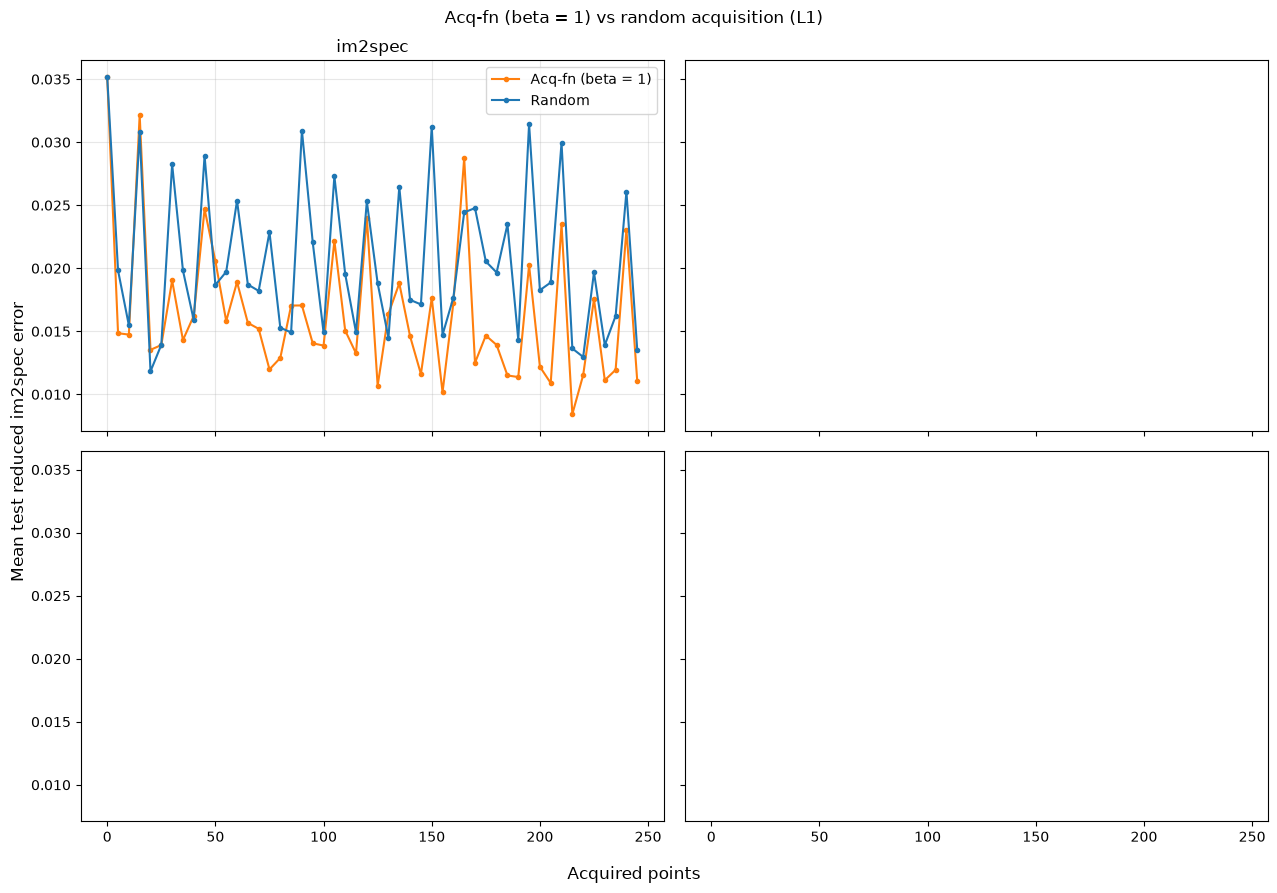

In [56]:
def calculate_mean_test_reduced_im2spec_error(output_dict):
    reduced_errors = output_dict["reduced_errors_im2spec"]
    test_indices = output_dict["test_indices"]

    if len(reduced_errors) != len(test_indices):
        raise ValueError(
            "reduced_errors_im2spec and test_indices have different iteration counts"
        )

    return np.asarray([
        np.mean(np.asarray(errors)[np.asarray(indices, dtype=int)])
        for errors, indices in zip(reduced_errors, test_indices)
    ])


model_configs = {
    "im2spec": "appendpad",
    #"im2spec_attn": "appendpad",
    #"FNO": "appendinterpolate",
    #"FNO_attn": "appendinterpolate",
}
acquisition_colors = {"random": "tab:blue", "distance": "tab:orange"}
acquisition_labels = {
    "random": "Random",
    "distance": "Acq-fn (beta = 1)",
}
comparison_results = {}

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for ax, (model_type, append_mode) in zip(axes.flat, model_configs.items()):
    comparison_results[model_type] = {}

    for acquisition in ("distance", "random"):
        output_file = results_dir / (
            f"al_{model_type}_{error_type}_WS32_latent5_{append_mode}_"
            f"{acquisition_iterations}iters_{num_new_points}pts_"
            f"{acquisition}acq.h5"
        )
        if not output_file.exists():
            raise FileNotFoundError(output_file)

        output_dict = load_h5_ragged(output_file)
        mean_test_reduced_im2spec_error = (
            calculate_mean_test_reduced_im2spec_error(output_dict)
        )
        points_per_iteration = infer_num_new_points(output_dict, output_file)
        acquired_points = (
            np.arange(len(mean_test_reduced_im2spec_error))
            * points_per_iteration
        )

        comparison_results[model_type][acquisition] = {
            "output_file": output_file,
            "output_dict": output_dict,
            "mean_test_reduced_im2spec_error": (
                mean_test_reduced_im2spec_error
            ),
        }

        ax.plot(
            acquired_points,
            mean_test_reduced_im2spec_error,
            marker="o",
            markersize=3,
            color=acquisition_colors[acquisition],
            label=acquisition_labels[acquisition],
        )

    ax.set_title(model_type)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.supxlabel("Acquired points")
fig.supylabel("Mean test reduced im2spec error")
fig.suptitle(f"Acq-fn (beta = 1) vs random acquisition ({error_type})")
fig.tight_layout()
plt.show()

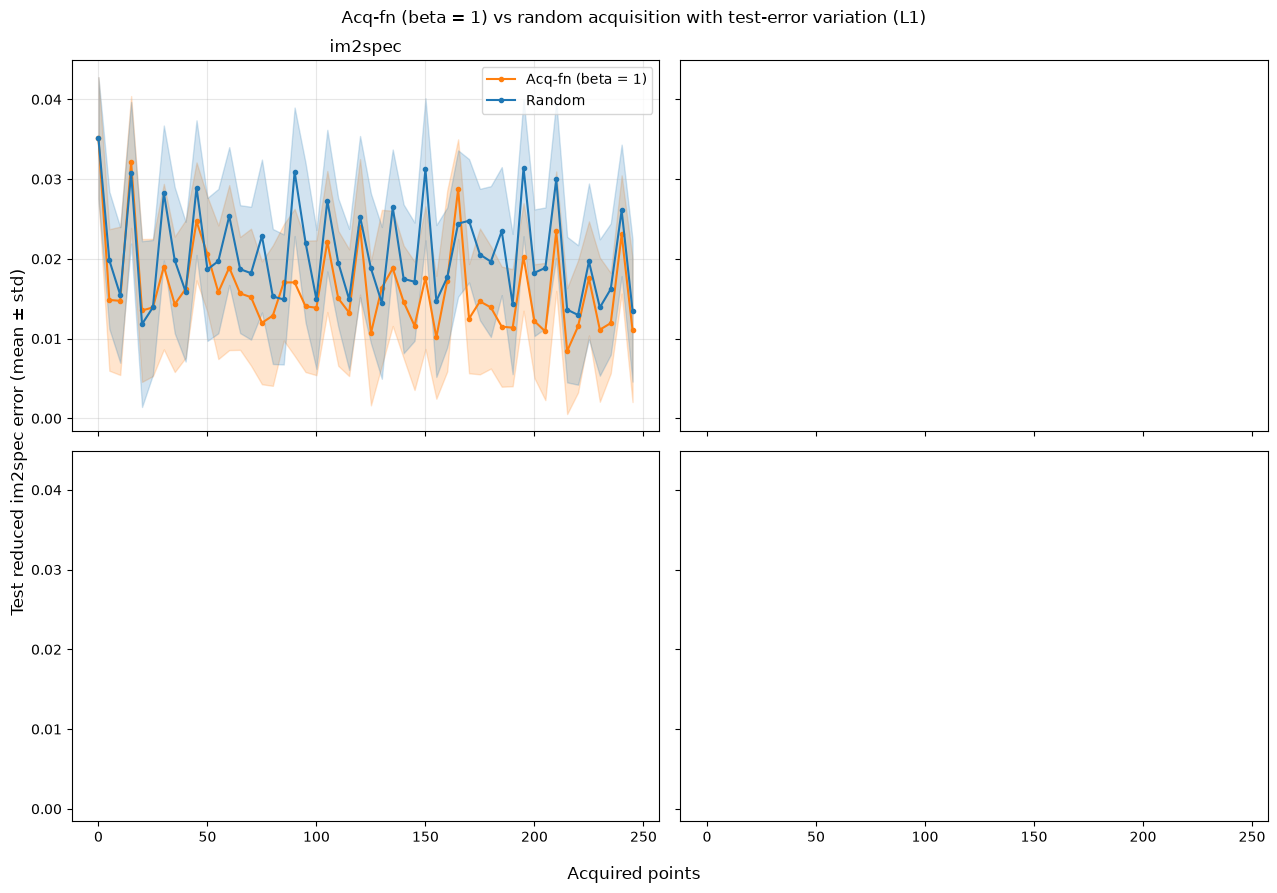

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for ax, (model_type, acquisition_results) in zip(
    axes.flat, comparison_results.items()
):
    for acquisition, result in acquisition_results.items():
        output_dict = result["output_dict"]
        output_file = result["output_file"]

        test_reduced_im2spec_errors = [
            np.asarray(errors)[np.asarray(indices, dtype=int)]
            for errors, indices in zip(
                output_dict["reduced_errors_im2spec"],
                output_dict["test_indices"],
            )
        ]
        mean_errors = result["mean_test_reduced_im2spec_error"]
        std_errors = np.asarray([
            np.std(errors) for errors in test_reduced_im2spec_errors
        ])
        result["std_test_reduced_im2spec_error"] = std_errors

        points_per_iteration = infer_num_new_points(output_dict, output_file)
        acquired_points = np.arange(len(mean_errors)) * points_per_iteration

        mean_line = ax.plot(
            acquired_points,
            mean_errors,
            marker="o",
            markersize=3,
            color=acquisition_colors[acquisition],
            label=acquisition_labels[acquisition],
        )[0]
        ax.fill_between(
            acquired_points,
            mean_errors - std_errors,
            mean_errors + std_errors,
            color=mean_line.get_color(),
            alpha=0.2,
        )

    ax.set_title(model_type)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.supxlabel("Acquired points")
fig.supylabel("Test reduced im2spec error (mean ± std)")
fig.suptitle(
    f"Acq-fn (beta = 1) vs random acquisition with test-error variation "
    f"({error_type})"
)
fig.tight_layout()
plt.show()


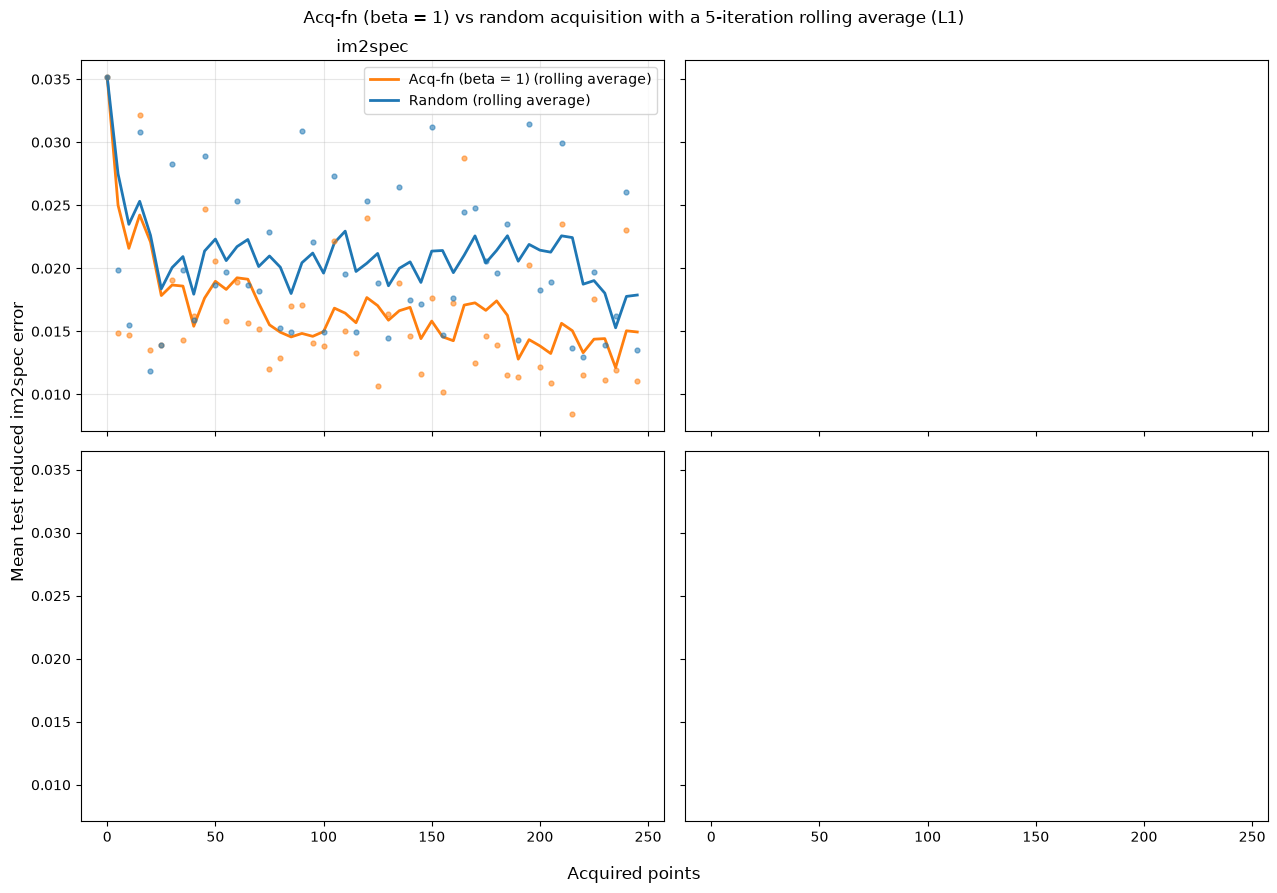

In [30]:

def rolling_average(array, window = 5):
  p_average = []

  array = np.array(array).squeeze()
  for i in range(len(array)):
    if i+1 < window:
      k = i+1
    else:
      k = window

    sum = 0
    for j in range(k):
      sum += array[i-j]

    p_average.append(sum/k)

  p_average = np.array(p_average).squeeze()

  return p_average


rolling_window = 5

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for ax, (model_type, acquisition_results) in zip(
    axes.flat, comparison_results.items()
):
    for acquisition, result in acquisition_results.items():
        output_dict = result["output_dict"]
        output_file = result["output_file"]
        mean_errors = result["mean_test_reduced_im2spec_error"]

        points_per_iteration = infer_num_new_points(output_dict, output_file)
        acquired_points = np.arange(len(mean_errors)) * points_per_iteration
        rolling_mean_errors = rolling_average(
            mean_errors, window=rolling_window
        )

        rolling_line = ax.plot(
            acquired_points,
            rolling_mean_errors,
            linewidth=2,
            color=acquisition_colors[acquisition],
            label=f"{acquisition_labels[acquisition]} (rolling average)",
        )[0]
        ax.scatter(
            acquired_points,
            mean_errors,
            color=rolling_line.get_color(),
            s=12,
            alpha=0.55,
            zorder=3,
        )

    ax.set_title(model_type)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.supxlabel("Acquired points")
fig.supylabel("Mean test reduced im2spec error")
fig.suptitle(
    f"Acq-fn (beta = 1) vs random acquisition with a "
    f"{rolling_window}-iteration "
    f"rolling average ({error_type})"
)
fig.tight_layout()
plt.show()


In [32]:
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone -b ayush_dev --single-branch https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

In [33]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom


try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)



import os
import numpy as np
import matplotlib.pyplot as plt
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis
from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec, im2spec_attn
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior, append_training_set
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution, plot_scale_specific_error_and_acquisition_maps
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1
from mpl_toolkits.axes_grid1 import make_axes_locatable

File import successful.


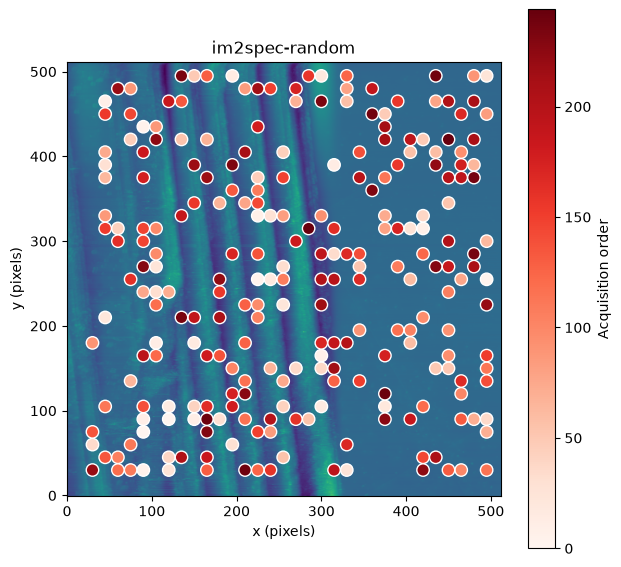

In [49]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Load STM morphology image ---
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"
img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")

full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

# --- Load acquisition results (im2spec only) ---
results_dir = Path("active_learning_results_ms2")
output_file = results_dir / "al_im2spec_L1_WS32_latent5_appendpad_50iters_5pts_randomacq.h5"
output_dict = load_h5_ragged(output_file)

# Reconstruct acquisition order from train_indices
train_sets = output_dict["train_indices"]
acq_order = []
for t in range(1, len(train_sets)):
    prev = set(train_sets[t-1])
    curr = set(train_sets[t])
    new = list(curr - prev)
    acq_order.extend(new)
acq_order = np.asarray(acq_order, dtype=int)

# Coordinates from last iteration
coords = np.asarray(output_dict["reduced_coords"][-1])
acquired_coords = coords[acq_order]

# Color by acquisition sequence
acq_seq = np.arange(len(acq_order))

# --- Plot morphology with acquisition dots ---
plt.figure(figsize=(7,7))
plt.imshow(full_image * 0.4833, cmap="viridis", origin="lower")
sc = plt.scatter(
    acquired_coords[:,0],
    acquired_coords[:,1],
    c=acq_seq,
    cmap="Reds",
    s=80,
    edgecolors="white",
    linewidths=1,
)
plt.colorbar(sc, label="Acquisition order")
plt.axis("on")
plt.title("im2spec-random")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.show()

